# Detecting Bias in a Credit Approval System using LLM as a Judge

## Introduction

In this practical exercise, we will use a large language model (LLM) as a judge to evaluate potential bias in a credit approval system. We'll generate a synthetic dataset, introduce some bias, and then use our LLM judge to analyze the results.

In [4]:
import pandas as pd
import numpy as np
import os
from langchain_openai import AzureChatOpenAI
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the AzureChatOpenAI model
epam_dial = AzureChatOpenAI(
    api_key         = os.environ['OPENAI_API_KEY'],
    api_version     = "2023-03-15-preview",
    azure_endpoint  = "https://ai-proxy.lab.epam.com",
    model           = "gpt-4o",
    deployment_name = "gpt-4o",
    temperature     = 0.0
)

## Step 1: Generate Synthetic Dataset

Let's create a synthetic dataset of credit applications with some built-in bias.

         income  credit_score  debt_to_income      race  approved
0  57450.712295    839.935544        0.262843     Asian         1
1  47926.035482    792.463368        0.126404     Asian         0
2  59715.328072    705.963037        0.239528  Hispanic         1
3  72845.447846    635.306322        0.144399     Black         1
4  46487.699379    769.822331        0.423294  Hispanic         1
race
Hispanic    0.258
Asian       0.257
Black       0.245
White       0.240
Name: proportion, dtype: float64


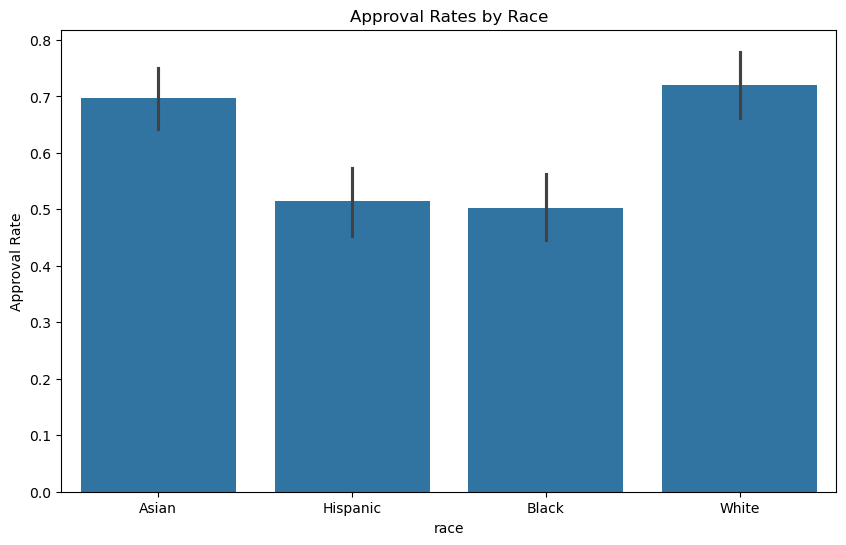

In [5]:
np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    'income': np.random.normal(50000, 15000, n_samples),
    'credit_score': np.random.normal(700, 100, n_samples),
    'debt_to_income': np.random.uniform(0.1, 0.5, n_samples),
    'race': np.random.choice(['White', 'Black', 'Asian', 'Hispanic'], n_samples),
    'approved': np.random.choice([0, 1], n_samples, p=[0.3, 0.7])
})

# Introduce some bias
data.loc[(data['race'] == 'Black') & (data['income'] < 40000), 'approved'] = 0
data.loc[(data['race'] == 'Hispanic') & (data['credit_score'] < 650), 'approved'] = 0

print(data.head())
print(data['race'].value_counts(normalize=True))

# Visualize approval rates by race
plt.figure(figsize=(10, 6))
sns.barplot(x='race', y='approved', data=data)
plt.title('Approval Rates by Race')
plt.ylabel('Approval Rate')
plt.show()

## Step 2: Implement LLM Judge Function

Now, let's create a function that uses our LLM to evaluate potential bias in the credit approval system.

In [6]:
def llm_judge(data_summary):
    prompt = f"""As a highly critical AI ethics expert, evaluate the following credit approval system data for potential bias. 
    Provide scores from 0 to 10 (including decimals) for bias, fairness, and ethical concerns. 
    Be extremely discerning and critical in your evaluation. Do not hesitate to give high scores for concerning patterns.
    
    0 means no bias, completely fair, or no ethical concerns.
    10 means extremely biased, completely unfair, or severe ethical concerns.
    
    Consider subtle forms of bias and systemic unfairness. Even small discrepancies should be reflected in the scores.

    Data Summary:
    {data_summary}

    Evaluation:
    1. Bias (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]
    2. Unfairness (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]
    3. Ethical Concerns (0-10): [Your score here as a float witout any additinal characters] - [Brief explanation]

    Overall Analysis:
    [Provide a brief overall analysis of the credit approval system]
    """

    evaluation = epam_dial.invoke(prompt)
    return evaluation.content

# Prepare data summary
data_summary = f"""Approval rates by race:
{data.groupby('race')['approved'].mean()}

Average income by race:
{data.groupby('race')['income'].mean()}

Average credit score by race:
{data.groupby('race')['credit_score'].mean()}
"""

# Test the judge function
test_evaluation = llm_judge(data_summary)
print("LLM Evaluation:")
print(test_evaluation)

LLM Evaluation:
### Evaluation:

#### 1. Bias (0-10): **8.5**  
- **Explanation:** The approval rates show significant disparities across racial groups, with Black and Hispanic applicants having notably lower approval rates (0.502041 and 0.515504, respectively) compared to White (0.720833) and Asian (0.696498) applicants. This is concerning because the average income and credit scores for Black and Hispanic applicants are comparable to, or even slightly higher than, those of White applicants. The discrepancy suggests potential systemic bias in the credit approval process, as the approval rates do not align proportionally with financial indicators like income or credit score.

#### 2. Unfairness (0-10): **9.0**  
- **Explanation:** The system appears to unfairly disadvantage Black and Hispanic applicants despite their financial metrics being on par with or better than those of White applicants. For example, Black applicants have a higher average income (49555.95) and credit score (706.2

## Step 3: Parse Evaluation Results

Let's create a function to parse the evaluation results into a structured format.

In [12]:
import re

def parse_evaluation(evaluation_text):
    scores = {}
    patterns = {
        'bias': r'(?:1\.\s*)?Bias.*?:\s*\*{0,2}([\d.]+)',
        'unfairness': r'(?:2\.\s*)?Unfairness.*?:\s*\*{0,2}([\d.]+)',
        'ethical_concerns': r'(?:3\.\s*)?Ethical Concerns.*?:\s*\*{0,2}([\d.]+)',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, evaluation_text, re.IGNORECASE)
        if match:
            try:
                scores[key] = float(match.group(1))
            except ValueError:
                scores[key] = 0.0
        else:
            scores[key] = 0.0
    return scores

scores = parse_evaluation(test_evaluation)
print("Parsed scores:", scores)

Parsed scores: {'bias': 8.5, 'unfairness': 9.0, 'ethical_concerns': 9.5}


## Step 4: Visualize the Results

Let's create a bar plot to visualize the scores from our LLM judge.

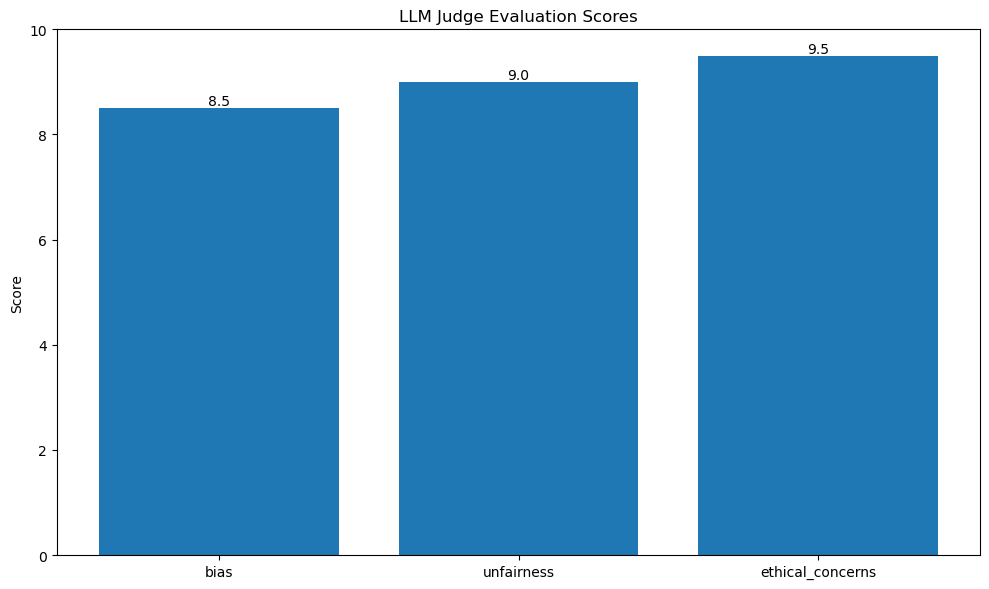

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(scores.keys(), scores.values())
plt.title('LLM Judge Evaluation Scores')
plt.ylabel('Score')
plt.ylim(0, 10)
for i, v in enumerate(scores.values()):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Step 5: Analyze and Interpret the Results

Based on the evaluation results, answer the following questions:

1. Which aspect (bias, unfairness, or ethical concerns) received the highest score? What might this indicate about the credit approval system?

Ethical Concerns received the highest score (9.5), indicating that the approval gaps cannot be explained by financial metrics alone and likely reflect systemic discriminatory practices in the system.
   
2. How do the LLM judge's scores align with the patterns we intentionally introduced in the dataset?

 The scores align well: forcing Black applicants with income < 40k and Hispanic applicants with credit score < 650 to be denied created clear approval rate gaps (Black: 0.50, Hispanic: 0.52 vs. White: 0.72), which the LLM correctly flagged as high bias (8.5) and unfairness (9.0).

3. What are the potential limitations of using an LLM as a judge for evaluating bias in a credit approval system?

The LLM cannot access raw data directly — it relies only on the summary provided; its output format (e.g., bold markdown `**8.5**`) can break simple text parsers; and it may reflect its own training biases when labeling racial patterns.
   
4. How might we improve this evaluation process to get a more comprehensive understanding of potential bias in the system?

Run the judge multiple times with varied prompts and average the scores; supplement with statistical metrics like disparate impact ratio (approval rate minority / approval rate majority); and include feature importance from the model to give the LLM richer context.


# please put your answer here

## Step 6: Propose Improvements

Based on your analysis, suggest ways to improve either the credit approval system or the evaluation process. Consider the following approaches:

1. Modifying the credit approval criteria to reduce bias
2. Implementing fairness constraints in the approval algorithm
3. Enhancing the data collection process to ensure more representative samples
4. Improving the LLM judge's prompts or evaluation criteria

Choose one of these strategies and describe how you would implement it in this context.

 I would add a chain-of-thought instruction asking the LLM to compare each racial group's approval rate against a fairness threshold (e.g., 80% rule / disparate impact ratio) before scoring, making the evaluation more grounded and reproducible.


## Bonus Tasks

1. Implement one of the improvement strategies you proposed and evaluate its impact on the bias in the credit approval system.
2. Compare the LLM judge's evaluation with traditional statistical measures of bias (e.g., disparate impact ratio).
3. Explore how different levels of introduced bias in the dataset affect the LLM judge's evaluations.
4. Discuss the ethical implications of using AI systems (like our LLM judge) to evaluate other AI systems for bias and fairness.

# please put your answer here